## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [3]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_2010-2021.csv', encoding=enc)

In [4]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01,2010,1,2009-12-07,39.662866,22.635299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.662866,22.635299,14407.0,14025.0,39.662866,22.635299,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,2010-01-01,39.650181,22.650104,0.000441,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000441,0.000441
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-16,2010,1,2009-12-07,39.662866,22.635299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,39.662866,22.635299,14295.0,13485.0,39.662866,22.635299,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,2010-01-16,39.650181,22.650104,18.932700,2010-01-09,2010-01-02,2010-01-09,2010-01-02,13.140626,18.916778
2,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-01,2010,1,2009-12-07,39.752697,22.707165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.752697,22.707165,14367.0,NaN,39.752697,22.707165,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,2010-01-01,39.750182,22.750104,0.030362,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.030362,0.030362
3,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-16,2010,1,2009-12-07,39.752697,22.707165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,39.752697,22.707165,14093.0,13628.0,39.752697,22.707165,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,2010-01-16,39.750182,22.750104,50.056047,2010-01-09,2010-01-02,2010-01-09,2010-01-02,33.498169,49.542448
4,αγιας,θεσσαλιας,22.73031,39.79054,2010-01-01,2010,1,2009-12-07,39.788630,22.729622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.788630,22.729622,14227.0,NaN,39.788630,22.729622,13896.166667,13803.75,13802.111111,13714.000000,14134.000000,13810.285714,14421.769231,13843.333333,2010-01-01,39.750182,22.750104,0.030362,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.030362,0.030362


In [5]:
wnv_file.head()

,lau1,nuts2,dt_placement,case
0,αγιας,θεσσαλιας,2010-06-01,0
1,αγιας,θεσσαλιας,2010-06-16,0
2,αγιας,θεσσαλιας,2010-07-01,0
3,αγιας,θεσσαλιας,2010-07-16,1
4,αγιας,θεσσαλιας,2010-08-01,0


In [6]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [7]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [8]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [9]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14407.0,14025.0,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,0.000441,0.000441,0.000441
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14295.0,13485.0,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,18.932700,13.140626,18.916778
2,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14367.0,NaN,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,0.030362,0.030362,0.030362
3,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14093.0,13628.0,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,50.056047,33.498169,49.542448
4,αγιας,θεσσαλιας,22.73031,39.79054,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14227.0,NaN,13896.166667,13803.75,13802.111111,13714.000000,14134.000000,13810.285714,14421.769231,13843.333333,0.030362,0.030362,0.030362


In [10]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,αγιας,θεσσαλιας,2010-06-01,0
1,αγιας,θεσσαλιας,2010-06-16,0
2,αγιας,θεσσαλιας,2010-07-01,0
3,αγιας,θεσσαλιας,2010-07-16,1
4,αγιας,θεσσαλιας,2010-08-01,0


In [11]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

list1 = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
list2 = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")


['ρηγα φεραιου']

Length: 1


In [12]:
timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('ρηγα φερραιου','ρηγα φεραιου'))

In [13]:
## Check again

list1 = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
list2 = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

[]

Length: 0


In [14]:
merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [15]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14407.0,14025.0,14216.714286,13830.000000,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,0.000441,0.000441,0.000441,NaN
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14295.0,13485.0,14216.714286,13830.000000,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,18.932700,13.140626,18.916778,NaN
2,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14367.0,NaN,14225.500000,13773.400000,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,0.030362,0.030362,0.030362,NaN
3,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14093.0,13628.0,14225.500000,13773.400000,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,50.056047,33.498169,49.542448,NaN
4,αγιας,θεσσαλιας,22.73031,39.79054,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14227.0,NaN,13896.166667,13803.750000,13802.111111,13714.000000,14134.000000,13810.285714,14421.769231,13843.333333,0.030362,0.030362,0.030362,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36283,φαρσαλων,θεσσαλιας,22.45598,39.35493,2021-12-16,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14163.538462,13680.875000,14408.866667,13900.533333,14530.315789,13798.153846,14780.928571,14022.058824,1398.456442,53.314030,115.708345,NaN
36284,φαρσαλων,θεσσαλιας,22.45598,39.39086,2021-12-01,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14156.583333,13716.000000,14394.461538,13892.500000,14520.375000,13800.666667,14735.133333,14050.764706,1282.748097,153.097007,209.865133,NaN
36285,φαρσαλων,θεσσαλιας,22.45598,39.39086,2021-12-16,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14156.583333,13716.000000,14394.461538,13892.500000,14520.375000,13800.666667,14735.133333,14050.764706,1398.456442,53.314030,115.708345,NaN
36286,φαρσαλων,θεσσαλιας,22.59495,39.30103,2021-12-01,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14128.923077,13653.857143,14453.571429,13917.466667,14497.476190,13807.333333,14866.071429,13996.133333,1269.494836,158.110106,224.962835,NaN


In [16]:
merged = fillna(merged,{'case': 0})

In [17]:
merged['case'].value_counts()

0.0    35872
1.0      233
2.0      147
3.0       34
7.0        2
Name: case, dtype: int64

In [18]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [19]:
dataset = grouped.mean()

In [20]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2010-01-01,αγιας,θεσσαλιας,22.750267,39.710970,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.714286,14043.0,14144.784184,13859.708503,14085.070635,13813.365812,14450.201092,13902.285681,14604.807569,13996.636316,0.018327,0.018327,0.018327,0.0
1,2010-01-01,αλμυρου,θεσσαλιας,22.692366,39.136391,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14511.777778,14227.0,14186.415300,13889.104417,14237.209041,13872.420226,14562.648962,13970.509532,14710.665664,14064.744390,0.210382,0.210382,0.210382,0.0
2,2010-01-01,αλοννησου,θεσσαλιας,24.073790,39.328960,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14548.000000,14276.0,14251.272727,14165.875000,14178.833333,14059.285714,14412.266667,14153.944444,14600.080000,14184.529412,0.000000,0.000000,0.000000,0.0
3,2010-01-01,αργιθεας,θεσσαλιας,21.430513,39.221380,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13671.244444,13673.444444,13853.958333,13610.345238,14256.170635,13799.499573,14494.970238,13979.482143,49.209201,49.209201,49.209201,0.0
4,2010-01-01,βολου,θεσσαλιας,22.883800,39.351977,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14576.666667,NaN,14359.732143,13897.046296,14340.338384,13871.508929,14628.190476,13984.622938,14876.861477,14096.591800,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.553160,39.852112,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13933.387063,13681.367460,14200.925735,13893.654484,14283.901681,13796.241007,14616.180112,13932.598700,1202.290178,58.108282,87.904479,0.0
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.797560,39.635058,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14140.314423,13697.631349,14358.253773,13912.150104,14537.978095,13803.803680,14827.634685,14005.430544,1617.381678,66.377516,128.112311,0.0
7197,2021-12-16,τυρναβου,θεσσαλιας,22.343000,39.828472,2021.0,12.0,0.410104,0.187286,-0.272235,-0.187286,0.393206,0.184501,-0.26368,-0.184501,0.029704,0.058359,0.030164,0.058359,NaN,NaN,14036.815476,13722.609091,14303.707292,13897.720588,14491.201157,13824.337912,14753.932767,13972.226103,1244.257719,48.910871,86.194025,0.0
7198,2021-12-16,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14163.080342,13727.400000,14363.222278,13913.152256,14569.512821,13860.088889,14810.315873,14057.720044,1441.876840,55.608775,115.182489,0.0


In [21]:
dataset = dataset.astype({'case': 'int'})

In [22]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [23]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [24]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [25]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [26]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,αγιας,θεσσαλιας,22.75027,39.71097,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.714286,14043.0,14144.784184,13859.708503,14085.070635,13813.365812,14450.201092,13902.285681,14604.807569,13996.636316,0.018327,0.018327,0.018327,0,1,53,45.76610,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
1,2010-01-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14511.777778,14227.0,14186.415300,13889.104417,14237.209041,13872.420226,14562.648962,13970.509532,14710.665664,14064.744390,0.210382,0.210382,0.210382,0,1,53,45.23937,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
2,2010-01-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14548.000000,14276.0,14251.272727,14165.875000,14178.833333,14059.285714,14412.266667,14153.944444,14600.080000,14184.529412,0.000000,0.000000,0.000000,0,1,53,46.11198,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
3,2010-01-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13671.244444,13673.444444,13853.958333,13610.345238,14256.170635,13799.499573,14494.970238,13979.482143,49.209201,49.209201,49.209201,0,1,53,44.69433,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
4,2010-01-01,βολου,θεσσαλιας,22.88380,39.35198,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14576.666667,NaN,14359.732143,13897.046296,14340.338384,13871.508929,14628.190476,13984.622938,14876.861477,14096.591800,0.000000,0.000000,0.000000,0,1,53,45.52194,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.55316,39.85211,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13933.387063,13681.367460,14200.925735,13893.654484,14283.901681,13796.241007,14616.180112,13932.598700,1202.290178,58.108282,87.904479,0,16,50,45.79122,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.79756,39.63506,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14140.314423,13697.631349,14358.253773,13912.150104,14537.978095,13803.803680,14827.634685,14005.430544,1617.381678,66.377516,128.112311,0,16,50,45.23352,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
7197,2021-12-16,τυρναβου,θεσσαλιας,22.34300,39.82847,2021,12,0.410104,0.187286,-0.272235,-0.187286,0.393206,0.184501,-0.26368,-0.184501,0.029704,0.058359,0.030164,0.058359,NaN,NaN,14036.815476,13722.609091,14303.707292,13897.720588,14491.201157,13824.337912,14753.932767,13972.226103,1244.257719,48.910871,86.194025,0,16,50,45.66746,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
7198,2021-12-16,φαρκαδονας,θεσσαλιας,22.02056,39.60375,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14163.080342,13727.400000,14363.222278,13913.152256,14569.512821,13860.088889,14810.315873,14057.720044,1441.876840,55.608775,115.182489,0,16,50,45.31404,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742


<AxesSubplot:>

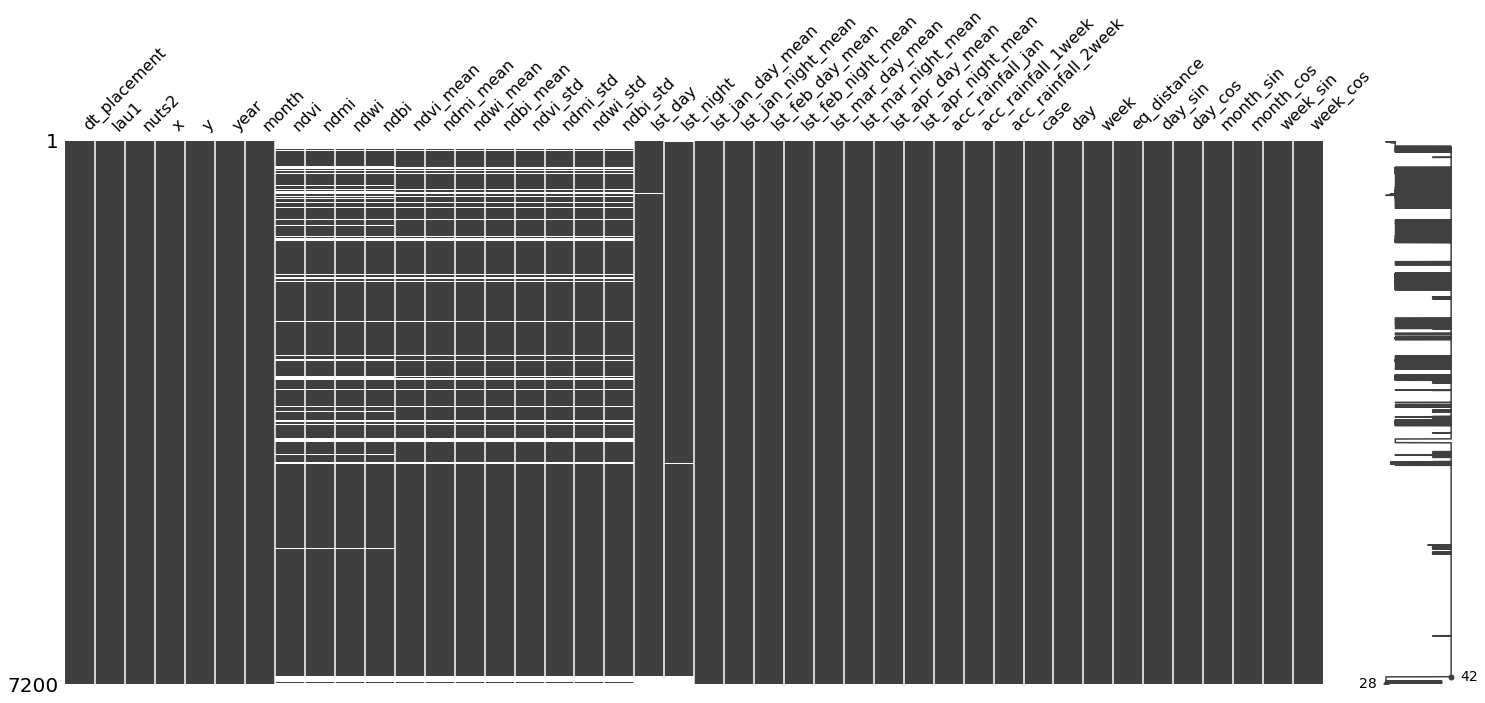

In [27]:
missingno.matrix(dataset)

In [28]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [29]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [30]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [31]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [32]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας,661.8,17.3,10705.00
1,αλμυρου,905.4,20.6,16004.00
2,αλοννησου,129.6,21.2,3153.00
3,αργιθεας,372.9,9.3,3515.00
4,βολου,385.6,374.6,138865.00
...,...,...,...,...
20,τεμπων,576.7,23.8,11.99
21,τρικκαιων,607.6,133.9,78508.00
22,τυρναβου,525.3,47.7,22252.00
23,φαρκαδονος,368.7,36.3,11348.00


In [33]:
list1 = dataset["lau1"].drop_duplicates().sort_values().tolist()
list2 = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

['καλαμπακας', 'λαρισαιων', 'φαρκαδονας']

Length: 3


In [34]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('μετεωρων','καλαμπακας'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('λαρισας','λαρισαιων'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('φαρκαδονος','φαρκαδονας'))


In [35]:
list1 = dataset["lau1"].drop_duplicates().sort_values().tolist()
list2 = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

[]

Length: 0


In [36]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

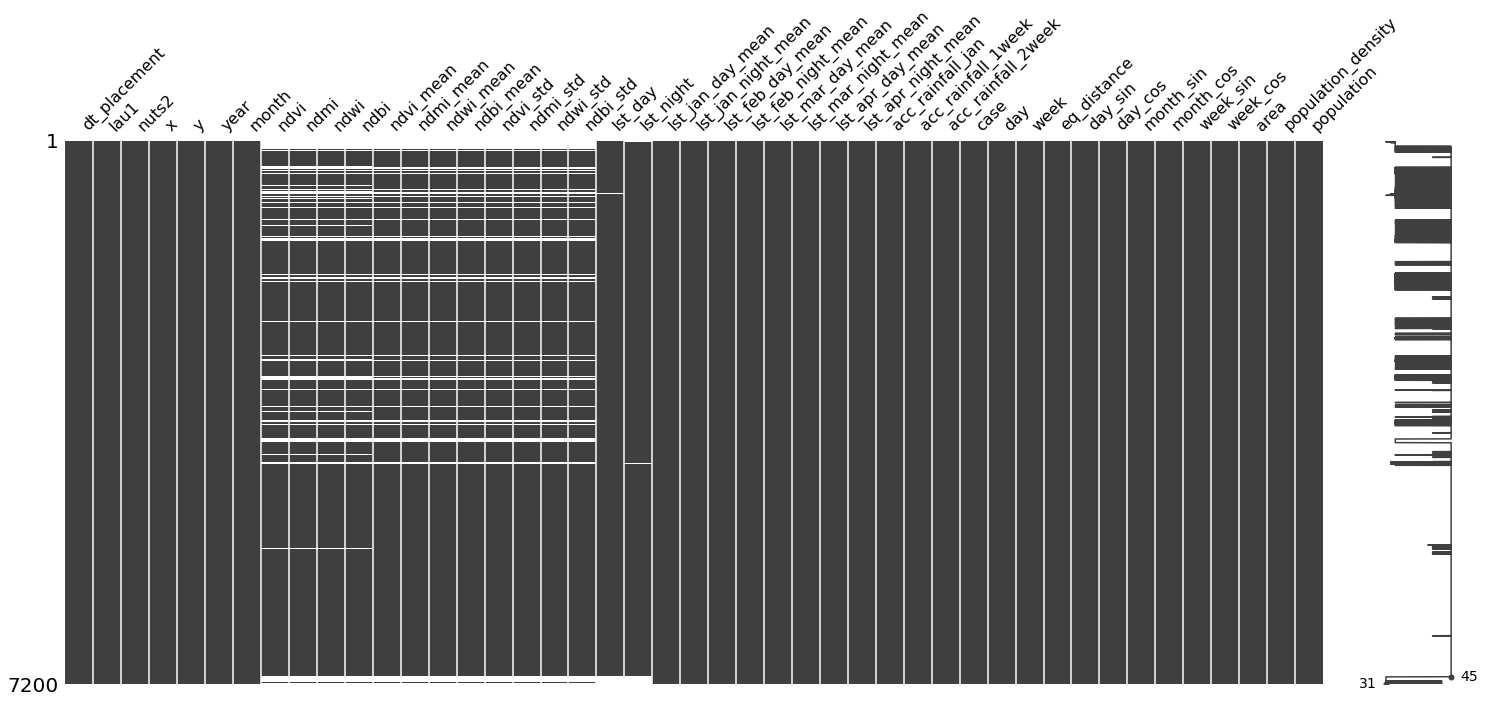

In [37]:
missingno.matrix(dataset)

In [38]:
missing = describe_dataframe(dataset)

f:\My Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Modules\preprocessing_utils.py:240: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_desc = df_desc.append({'Column': col,
f:\My Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Modules\preprocessing_utils.py:240: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_desc = df_desc.append({'Column': col,
f:\My Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Modules\preprocessing_utils.py:240: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_desc = df_desc.append({'Column': col,
f:\My Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Modules\preprocessing_utils.py:240: FutureWarning: The frame.append method is deprecated and will be

In [39]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2010-01-01,αγιας,θεσσαλιας,22.75027,39.71097,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.714286,14043.0,14144.784184,13859.708503,14085.070635,13813.365812,14450.201092,13902.285681,14604.807569,13996.636316,0.018327,0.018327,0.018327,0,1,53,45.76610,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,661.8,17.3,10705.00
1,2010-01-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14511.777778,14227.0,14186.415300,13889.104417,14237.209041,13872.420226,14562.648962,13970.509532,14710.665664,14064.744390,0.210382,0.210382,0.210382,0,1,53,45.23937,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,905.4,20.6,16004.00
2,2010-01-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14548.000000,14276.0,14251.272727,14165.875000,14178.833333,14059.285714,14412.266667,14153.944444,14600.080000,14184.529412,0.000000,0.000000,0.000000,0,1,53,46.11198,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,129.6,21.2,3153.00
3,2010-01-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13671.244444,13673.444444,13853.958333,13610.345238,14256.170635,13799.499573,14494.970238,13979.482143,49.209201,49.209201,49.209201,0,1,53,44.69433,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,372.9,9.3,3515.00
4,2010-01-01,βολου,θεσσαλιας,22.88380,39.35198,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14576.666667,NaN,14359.732143,13897.046296,14340.338384,13871.508929,14628.190476,13984.622938,14876.861477,14096.591800,0.000000,0.000000,0.000000,0,1,53,45.52194,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,385.6,374.6,138865.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.55316,39.85211,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13933.387063,13681.367460,14200.925735,13893.654484,14283.901681,13796.241007,14616.180112,13932.598700,1202.290178,58.108282,87.904479,0,16,50,45.79122,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,576.7,23.8,11.99
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.79756,39.63506,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14140.314423,13697.631349,14358.253773,13912.150104,14537.978095,13803.803680,14827.634685,14005.430544,1617.381678,66.377516,128.112311,0,16,50,45.23352,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,607.6,133.9,78508.00
7197,2021-12-16,τυρναβου,θεσσαλιας,22.34300,39.82847,2021,12,0.410104,0.187286,-0.272235,-0.187286,0.393206,0.184501,-0.26368,-0.184501,0.029704,0.058359,0.030164,0.058359,NaN,NaN,14036.815476,13722.609091,14303.707292,13897.720588,14491.201157,13824.337912,14753.932767,13972.226103,1244.257719,48.910871,86.194025,0,16,50,45.66746,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,525.3,47.7,22252.00
7198,2021-12-16,φαρκαδονας,θεσσαλιας,22.02056,39.60375,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14163.080342,13727.400000,14363.222278,13913.152256,14569.512821,13860.088889,14810.315873,14057.720044,1441.876840,55.608775,115.182489,0,16,50,45.31404,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,368.7,36.3,11348.00


In [40]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2021.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2010-01-01,8
1,22.692366,39.136391,2010-01-01,1
2,24.073790,39.328960,2010-01-01,1
3,21.430513,39.221380,2010-01-01,12
4,22.883800,39.351977,2010-01-01,1
...,...,...,...,...
7195,22.553160,39.852112,2021-12-16,59
7196,21.797560,39.635058,2021-12-16,36
7197,22.343000,39.828472,2021-12-16,12
7198,22.020557,39.603750,2021-12-16,49


In [41]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [42]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [43]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0008571819480130482


In [44]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [45]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp/ipykernel_6012/4002766964.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])
C:\Users\dimit\AppData\Local\Temp/ipykernel_6012/4002766964.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])
C:\Users\dimit\AppData\Local\Temp/ipykernel_6012/4002766964.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])
C:\Users\dimit\AppData\Local\Temp/ipykernel_6012/4002766964.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_mosq = df_mosq.append(df_mosqui

In [46]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [47]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2010-01-01,αγιας,θεσσαλιας,22.75027,39.71097,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.714286,14043.0,14144.784184,13859.708503,14085.070635,13813.365812,14450.201092,13902.285681,14604.807569,13996.636316,0.018327,0.018327,0.018327,0,1,53,45.76610,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,17.3,10705.0,8
1,2010-01-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14511.777778,14227.0,14186.415300,13889.104417,14237.209041,13872.420226,14562.648962,13970.509532,14710.665664,14064.744390,0.210382,0.210382,0.210382,0,1,53,45.23937,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,20.6,16004.0,1
2,2010-01-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14548.000000,14276.0,14251.272727,14165.875000,14178.833333,14059.285714,14412.266667,14153.944444,14600.080000,14184.529412,0.000000,0.000000,0.000000,0,1,53,46.11198,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,21.2,3153.0,1
3,2010-01-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13671.244444,13673.444444,13853.958333,13610.345238,14256.170635,13799.499573,14494.970238,13979.482143,49.209201,49.209201,49.209201,0,1,53,44.69433,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,9.3,3515.0,10
4,2010-01-01,βολου,θεσσαλιας,22.88380,39.35198,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14576.666667,NaN,14359.732143,13897.046296,14340.338384,13871.508929,14628.190476,13984.622938,14876.861477,14096.591800,0.000000,0.000000,0.000000,0,1,53,45.52194,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,374.6,138865.0,13


<AxesSubplot:>

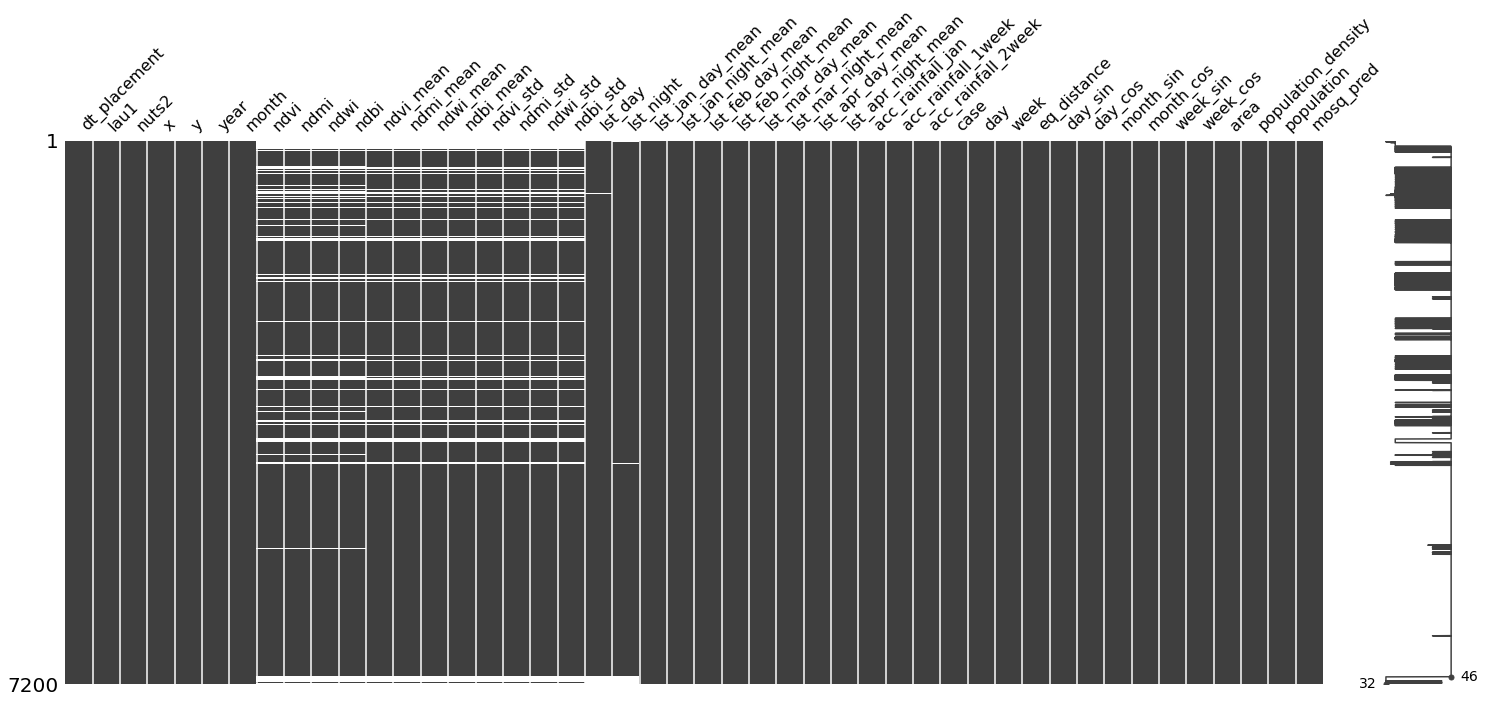

In [48]:
missingno.matrix(dataset)

In [49]:
dataset.reset_index(inplace=True, drop=True)

In [50]:
dataset = calculate_mosq_previous(dataset)

In [51]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

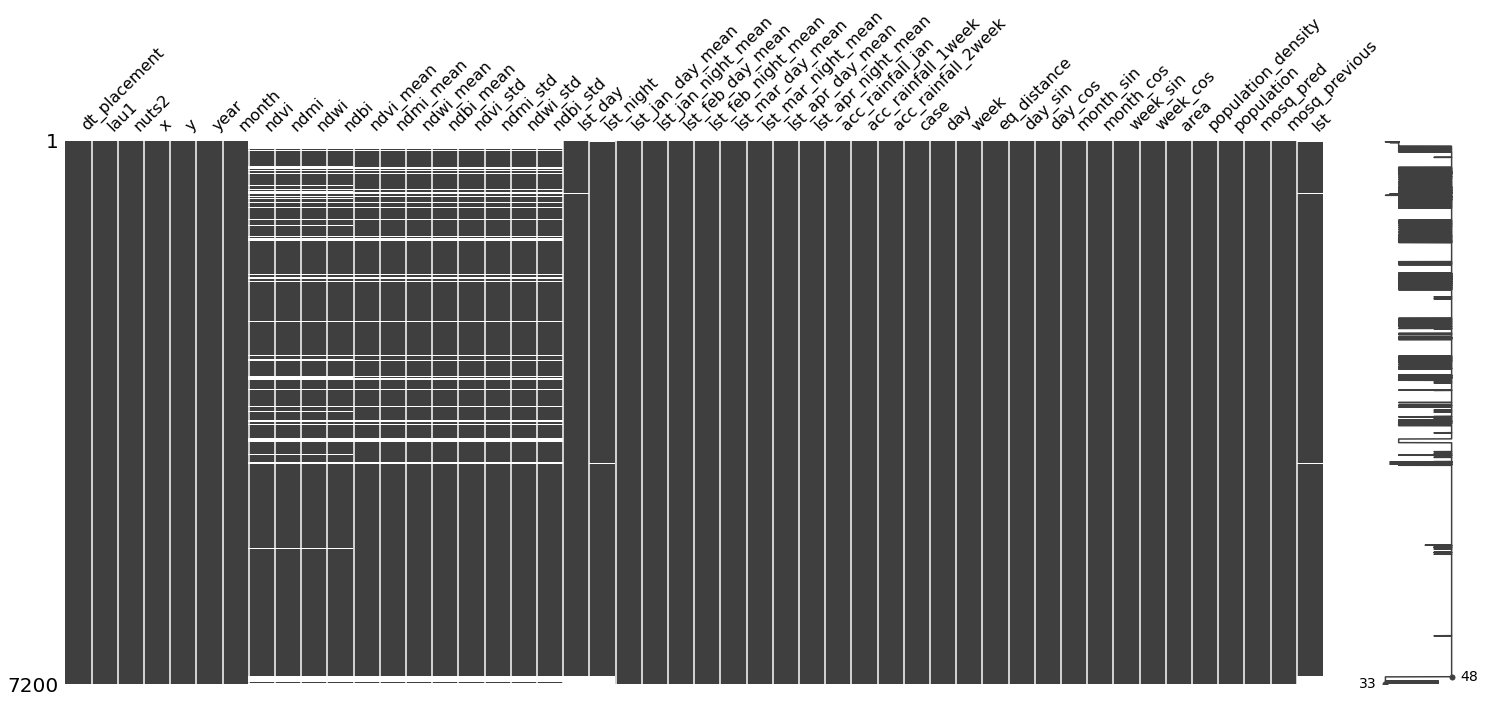

In [52]:
missingno.matrix(dataset)

In [53]:
dataset['case'].value_counts()

0    7127
1      47
2      20
3       5
7       1
Name: case, dtype: int64

In [54]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [55]:
dataset = convert_multiple_cases(dataset)

f:\My Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Modules\preprocessing_utils.py:326: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append([dataframe[dataframe[target_col] == case_count]] * (case_count - 1), ignore_index=True)


In [56]:
dataset['case'].value_counts()

0    7127
1     109
Name: case, dtype: int64

In [57]:
cols = dataset.columns

In [58]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'area', 'population_density',
       'population', 'mosq_pred', 'mosq_previous', 'lst'],
      dtype='object')

In [59]:
len(cols)

48

In [60]:
# check columns

In [63]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [64]:
len(final_columns)

48

In [65]:
dataset_final = dataset[final_columns].copy()

In [66]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-01-01,θεσσαλιας,αγιας,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,661.8,10705.0,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.177143,14.644286,7.71,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,0.018327,0.018327,0.018327,8,0,0
1,22.69237,39.13639,2010-01-01,θεσσαλιας,αλμυρου,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,905.4,16004.0,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.237778,17.085556,11.39,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,0.210382,0.210382,0.210382,1,0,0
2,24.07379,39.32896,2010-01-01,θεσσαλιας,αλοννησου,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,129.6,3153.0,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.090000,17.810000,12.37,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,0.000000,0.000000,0.000000,1,0,0
3,21.43051,39.22138,2010-01-01,θεσσαλιας,αργιθεας,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,372.9,3515.0,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,49.209201,49.209201,49.209201,10,0,0
4,22.88380,39.35198,2010-01-01,θεσσαλιας,βολου,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,385.6,138865.0,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.383333,NaN,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,0.000000,0.000000,0.000000,13,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7231,22.25731,39.56682,2019-07-16,θεσσαλιας,λαρισαιων,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,336.0,164381.0,483.9,45.39737,0.29367,-0.124991,-0.338048,0.124991,0.320056,-0.093117,-0.357234,0.093117,0.053954,0.05562,0.040355,0.05562,26.740000,33.020000,20.46,7.386889,-2.422889,15.627500,2.167179,23.428889,6.443099,24.036538,9.583651,73.760626,78.358841,642.383343,10,20,1
7232,22.25731,39.56682,2019-07-16,θεσσαλιας,λαρισαιων,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,336.0,164381.0,483.9,45.39737,0.29367,-0.124991,-0.338048,0.124991,0.320056,-0.093117,-0.357234,0.093117,0.053954,0.05562,0.040355,0.05562,26.740000,33.020000,20.46,7.386889,-2.422889,15.627500,2.167179,23.428889,6.443099,24.036538,9.583651,73.760626,78.358841,642.383343,10,20,1
7233,22.25731,39.56682,2019-07-16,θεσσαλιας,λαρισαιων,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,336.0,164381.0,483.9,45.39737,0.29367,-0.124991,-0.338048,0.124991,0.320056,-0.093117,-0.357234,0.093117,0.053954,0.05562,0.040355,0.05562,26.740000,33.020000,20.46,7.386889,-2.422889,15.627500,2.167179,23.428889,6.443099,24.036538,9.583651,73.760626,78.358841,642.383343,10,20,1
7234,22.25731,39.56682,2019-07-16,θεσσαλιας,λαρισαιων,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,336.0,164381.0,483.9,45.39737,0.29367,-0.124991,-0.338048,0.124991,0.320056,-0.093117,-0.357234,0.093117,0.053954,0.05562,0.040355,0.05562,26.740000,33.020000,20.46,7.386889,-2.422889,15.627500,2.167179,23.428889,6.443099,24.036538,9.583651,73.760626,78.358841,642.383343,10,20,1


In [67]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)